In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import seaborn as sns
from scipy.stats import t as t_dist
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Setting a seed means np.random produces the same numbers every run.
# Without this, your dataset would be different each time and checkpoint
# thresholds would not match.
np.random.seed(42)

from sklearn.preprocessing import PolynomialFeatures

import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: Models ───────────────────────────────────
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    HuberRegressor, RANSACRegressor,
    LogisticRegression, PoissonRegressor
)

# ── Scikit-learn: Preprocessing & Selection ────────────────
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    learning_curve, KFold, validation_curve
)

# ── Scikit-learn: Metrics ──────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Scikit-learn: Imputation ───────────────────────────────
#from sklearn.impute import SimpleImputer
#from sklearn.experimental import enable_iterative_imputer
#from sklearn.impute import IterativeImputer

# ── Statsmodels ────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [ ]:
#loading the data
teenh = pd.read_csv('digital_habits_vs_mental_health.csv')

In [ ]:
#vizualise the data
teenh.head(5)

,screen_time_hours,social_media_platforms_used,hours_on_TikTok,sleep_hours,stress_level,mood_score
0,10.3,2,5.3,4.4,10,5
1,6.5,5,3.5,6.2,8,8
2,9.1,4,2.8,6.6,7,8
3,6.5,3,2.5,6.5,7,9
4,2.1,3,1.2,7.8,2,10


In [ ]:
#analize the data
print(teenh.info())
print('*'*60)
print(teenh.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   screen_time_hours            100000 non-null  float64
 1   social_media_platforms_used  100000 non-null  int64  
 2   hours_on_TikTok              100000 non-null  float64
 3   sleep_hours                  100000 non-null  float64
 4   stress_level                 100000 non-null  int64  
 5   mood_score                   100000 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 4.6 MB
None
************************************************************
       screen_time_hours  social_media_platforms_used  hours_on_TikTok  \
count      100000.000000                100000.000000    100000.000000   
mean            6.003505                     2.997820         2.401433   
std             1.987073                     1.414452         1.079111   
min    

In [ ]:
#Check the data for missing or nan values

print(f"missing values:")
print(teenh.isna().sum())      # check missing values
print("")
print(f"NaN values:")
print(np.isnan(teenh).sum())   # count NaNs

missing values:
screen_time_hours              0
social_media_platforms_used    0
hours_on_TikTok                0
sleep_hours                    0
stress_level                   0
mood_score                     0
dtype: int64

NaN values:
screen_time_hours              0
social_media_platforms_used    0
hours_on_TikTok                0
sleep_hours                    0
stress_level                   0
mood_score                     0
dtype: int64


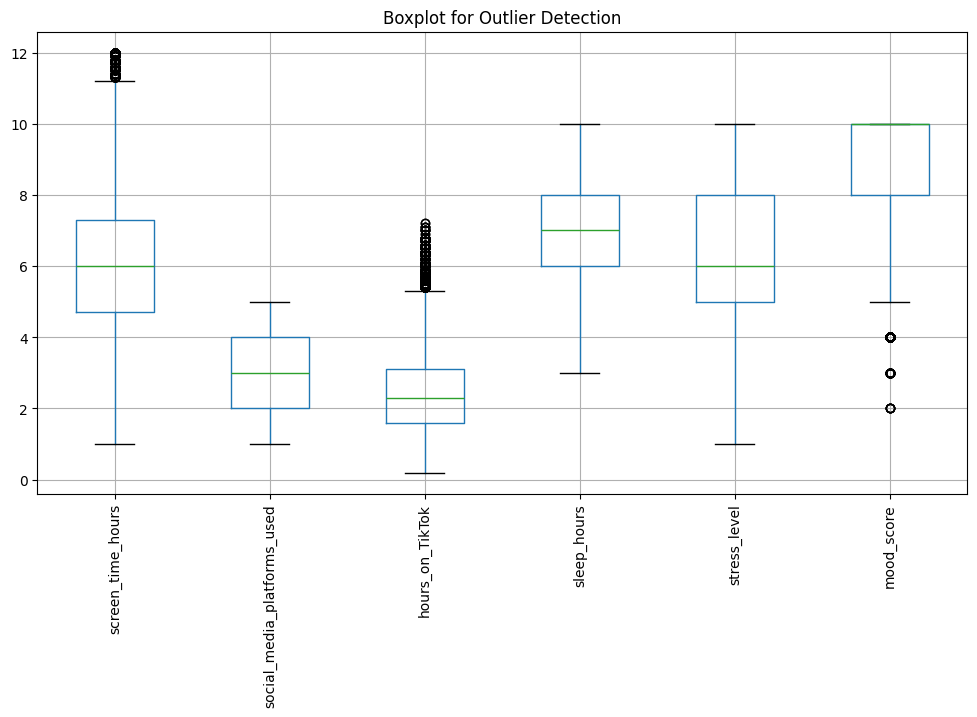

In [ ]:
#vizualzing the outliers
import matplotlib.pyplot as plt
import pandas as pd


teenh_df = pd.DataFrame(teenh)

plt.figure(figsize=(12,6))
teenh_df.boxplot(rot=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

#by plotting the data I can see we have a lot of outliers in screent time hours and tik tok hours

In [ ]:
#In this section of code I visualize the outliers in the graph
#then remove them and have a new shape data

Q1 = teenh_df.quantile(0.25)
Q3 = teenh_df.quantile(0.75)
IQR = Q3 - Q1

#outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#detect outliers
outliers = ((teenh_df < lower_bound) | (teenh_df > upper_bound))

#dount outliers per column
outlier_counts = outliers.sum()

print("Outliers per feature:\n")
print(outlier_counts)

#total rows with any outlier
rows_with_outliers = outliers.any(axis=1).sum()
print(f"\nTotal rows with outliers: {rows_with_outliers}")

#removing rows with outliers
clean_df = teenh_df[~outliers.any(axis=1)]

print(f"\nTotal rows without outliers: {clean_df.shape}")

Outliers per feature:

screen_time_hours              414
social_media_platforms_used      0
hours_on_TikTok                945
sleep_hours                      0
stress_level                     0
mood_score                     403
dtype: int64

Total rows with outliers: 1549

Total rows without outliers: (98451, 6)


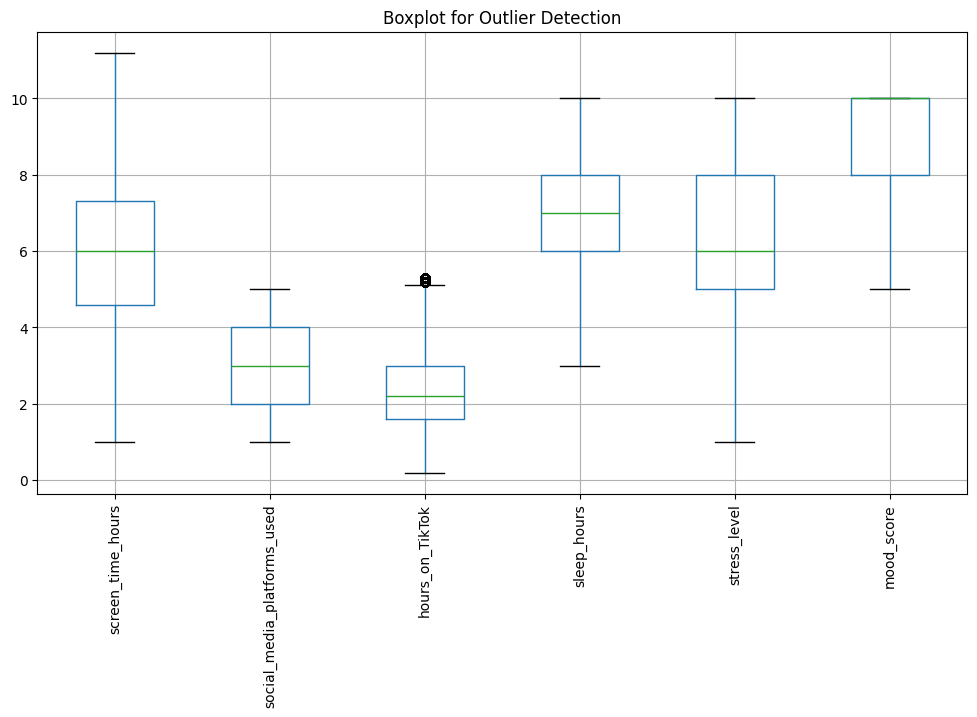

In [ ]:
#I once more graph my clean data to see the outliers have been removed
#vizualzing clean data
import matplotlib.pyplot as plt
import pandas as pd


teenh_df_1 = pd.DataFrame(clean_df)

plt.figure(figsize=(12,6))
teenh_df_1.boxplot(rot=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

# this new ouliers are created out of the new boundries we set of the new data
# we will keep those outliers, only cleaning the data once

In [ ]:
#In this part of the data I wanted to see de representation in numbers of
#new outliers foudn in the clean data
#outliers in the data

Q1 = clean_df.quantile(0.25)
Q3 = clean_df.quantile(0.75)
IQR = Q3 - Q1

#outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#detect outliers
outliers = ((clean_df < lower_bound) | (clean_df > upper_bound))

#dount outliers per column
outlier_counts = outliers.sum()

print("Outliers per feature:\n")
print(outlier_counts)

#total rows with any outlier
rows_with_outliers = outliers.any(axis=1).sum()
print(f"\nTotal rows with outliers: {rows_with_outliers}")

#removing rows with outliers
clean_df_2 = clean_df[~outliers.any(axis=1)]

print(f"\nTotal rows without outliers: {clean_df_2.shape}")

Outliers per feature:

screen_time_hours                0
social_media_platforms_used      0
hours_on_TikTok                462
sleep_hours                      0
stress_level                     0
mood_score                       0
dtype: int64

Total rows with outliers: 462

Total rows without outliers: (97989, 6)


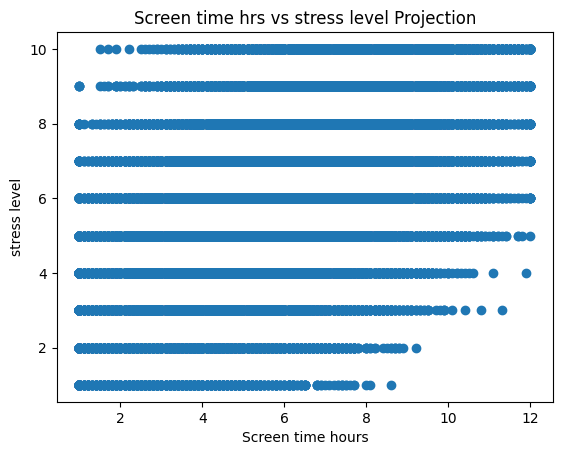

In [ ]:
# Making a graph to see how the data is plotted aganist our output data
plt.scatter(teenh.iloc[:, 0], teenh.iloc[:, 4])
plt.colorbar
plt.xlabel('Screen time hours')
plt.ylabel('stress level')
plt.title('Screen time hrs vs stress level Projection')
plt.show()

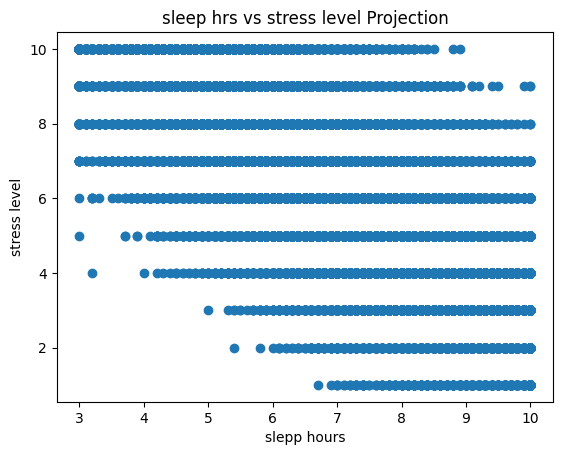

In [ ]:
# Making a graph to see how the data is plotted aganist our output data
plt.scatter(teenh.iloc[:, 3], teenh.iloc[:, 4])
plt.colorbar
plt.xlabel('slepp hours')
plt.ylabel('stress level')
plt.title('sleep hrs vs stress level Projection')
plt.show()

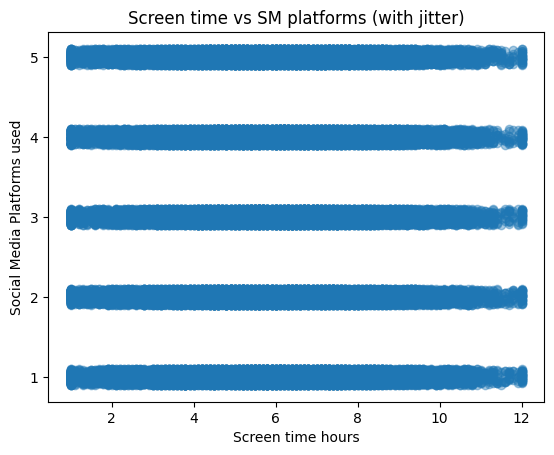

In [ ]:
# Making a graph to see how the data is plotted aganist other features
import numpy as np

x = teenh.iloc[:, 0]
y = teenh.iloc[:, 1]

# add small noise to y
y_jitter = y + np.random.uniform(-0.1, 0.1, size=len(y))

plt.scatter(x, y_jitter, alpha=0.4)

plt.xlabel('Screen time hours')
plt.ylabel('Social Media Platforms used')
plt.title('Screen time vs SM platforms (with jitter)')
plt.show()

In [ ]:

# Finding the correlation of the data against our stress level
clean_df.corr()["stress_level"]

,stress_level
screen_time_hours,0.476980
social_media_platforms_used,0.004802
hours_on_TikTok,0.461395
sleep_hours,-0.695013
stress_level,1.000000
mood_score,-0.627642


In [ ]:
#loading more libraries needed it
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

#Dividing the model and traning the model

X = clean_df[['screen_time_hours','social_media_platforms_used','hours_on_TikTok', 'sleep_hours', 'mood_score']].values
y = clean_df["stress_level"].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

from sklearn.linear_model import LassoCV

#Fit on traning data, with different models
#I tried different models and the combinations of different features to
#see which one perform better. Not much difference

#model_eval = LinearRegression().fit(X_train, y_train) #r2=0.7410
#model_eval = HuberRegressor(epsilon = 1.35).fit(X_train, y_train) #r2=0.7410
#model_eval = LassoCV(cv=5, random_state=42).fit(X_train, y_train) #r2=0.7410

#decided to use polynomail and Hyber regrassion, since hubber handles
#outliers, and we saw that we have some outliers in tiktok hours.
model_eval = Pipeline([           #r2=7430
    ('Scale', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
   ('model', HuberRegressor())
])

model_eval.fit(X_train, y_train)
y_pred = model_eval.predict(X_test)


y_train_pred = model_eval.predict(X_train)
y_test_pred = model_eval.predict(X_test)

#printing the y_train_pred and the y_test_predication
#to see how far off is the model from the traning predication to
#the testing predication
print("y_train_pred:")
print(y_train_pred[:5])
print(" ")
print("y_test_pred:")
print(y_test_pred[:5])



Training set size: 78760
Test set size: 19691
y_train_pred:
[5.73801619 6.13995671 6.38720506 5.12979096 5.55850231]
 
y_test_pred:
[5.32878315 8.07108728 6.61747166 7.68653272 6.13665968]


In [ ]:
#Metrics from Scratch
def rmse_scratch(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae_scratch(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_scratch(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

def adj_r2_scratch(y_true, y_pred, n_features):
    r2 = r2_scratch(y_true, y_pred)
    n = len(y_true)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

# Compute on train and test
metrics = {}

for name, yt, yp in [('Train', y_train, y_train_pred),
                       ('Test', y_test, y_test_pred)]:
    metrics[name] = {
        'RMSE': rmse_scratch(yt, yp),
        'MAE':  mae_scratch(yt, yp),
        'R²':   r2_scratch(yt, yp),
        'Adj R²': adj_r2_scratch(yt, yp, X_train.shape[1])
    }

metrics_df = pd.DataFrame(metrics).round(4)
print("=== Regression Metrics ===")
print(metrics_df)

# Verify with sklearn my outputs
rmse_sk = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_sk = r2_score(y_test, y_test_pred)
assert np.allclose(metrics['Test']['RMSE'], rmse_sk, rtol=0.01)
assert np.allclose(metrics['Test']['R²'], r2_sk, rtol=0.01)
print("\n✅ Scratch metrics match sklearn!")

print("\n=== Sklearn Metrics ===")
print("RMSE:", rmse_sk)
print("R²:", r2_sk)

=== Regression Metrics ===
         Train    Test
RMSE    1.0167  1.0205
MAE     0.8120  0.8138
R²      0.7482  0.7431
Adj R²  0.7482  0.7430

✅ Scratch metrics match sklearn!

=== Sklearn Metrics ===
RMSE: 1.0205197820741359
R²: 0.7430740231513991
